In [1]:
# Import required libraries for camera calibration and visualization
import cv2, json  # OpenCV for computer vision, json for data handling
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting images
np.set_printoptions(precision=2, suppress=True)  # Format numpy output for readability

In [2]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84


In [3]:
!pip install opencv-python==4.10.0.84

  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.5 MB)


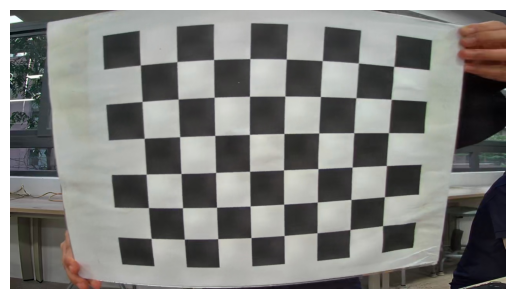

720 1280


In [4]:
# Load the first calibration image from the left camera 
image_path = f"new_calib20_8/{0:02d}.jpg"
img = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Get image dimensions (height and width)

h, w = img.shape[:2]

print(h,w)


In [5]:
board_shape = (8, 6)
objp = np.zeros((board_shape[1]*board_shape[0], 3), np.float32)
print(objp.shape)
print (objp)

(48, 3)
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [6]:
# Define the shape of the chessboard (number of inner corners per row and column)
board_shape = (8, 6)  # 9 columns and 6 rows of inner corners

# Size of one checker square in millimeters
checker_size = 26.7  # in mm

# Termination criteria for corner refinement: 
## cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER: Stop either when accuracy is reached or max iterations
## 30: Maximum number of iterations
## 0.001: Desired accuracy (epsilon)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points for the chessboard corners in 3D space (z=0)
## Create a grid of points for the chessboard corners

objp = np.zeros((board_shape[1]*board_shape[0], 3), np.float32)

objp[:, :2] = np.mgrid[0:board_shape[0], 0: board_shape[1]].T.reshape(-1, 2)

objp *= checker_size  # scale to mm

# Arrays to store object points (3D) and image points (2D) from all images
objpoints = []  # 3D points in board coords
imgpoints = []  # 2D points in image plane

# Image shape (width, height)
img_shape = (w, h)

# Collecting Calibration Points
We loop through multiple calibration images, detect and refine chessboard corners, and store the corresponding 3D object points and 2D image

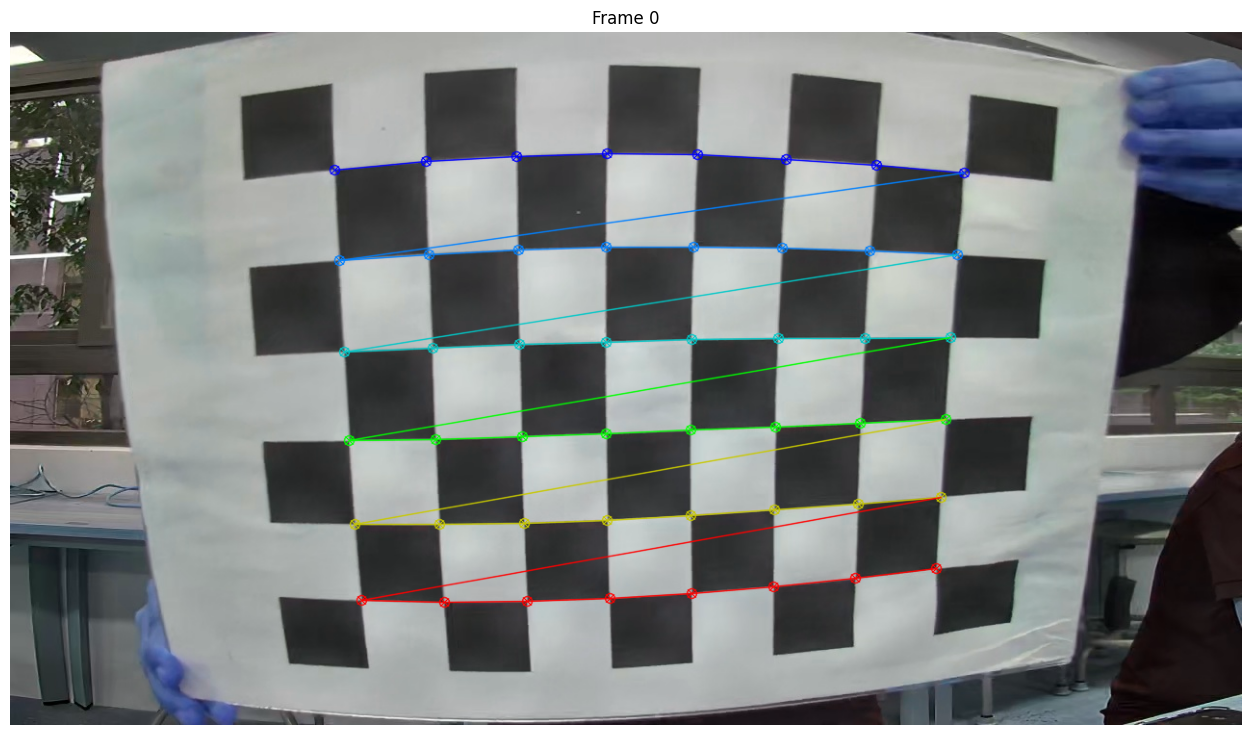

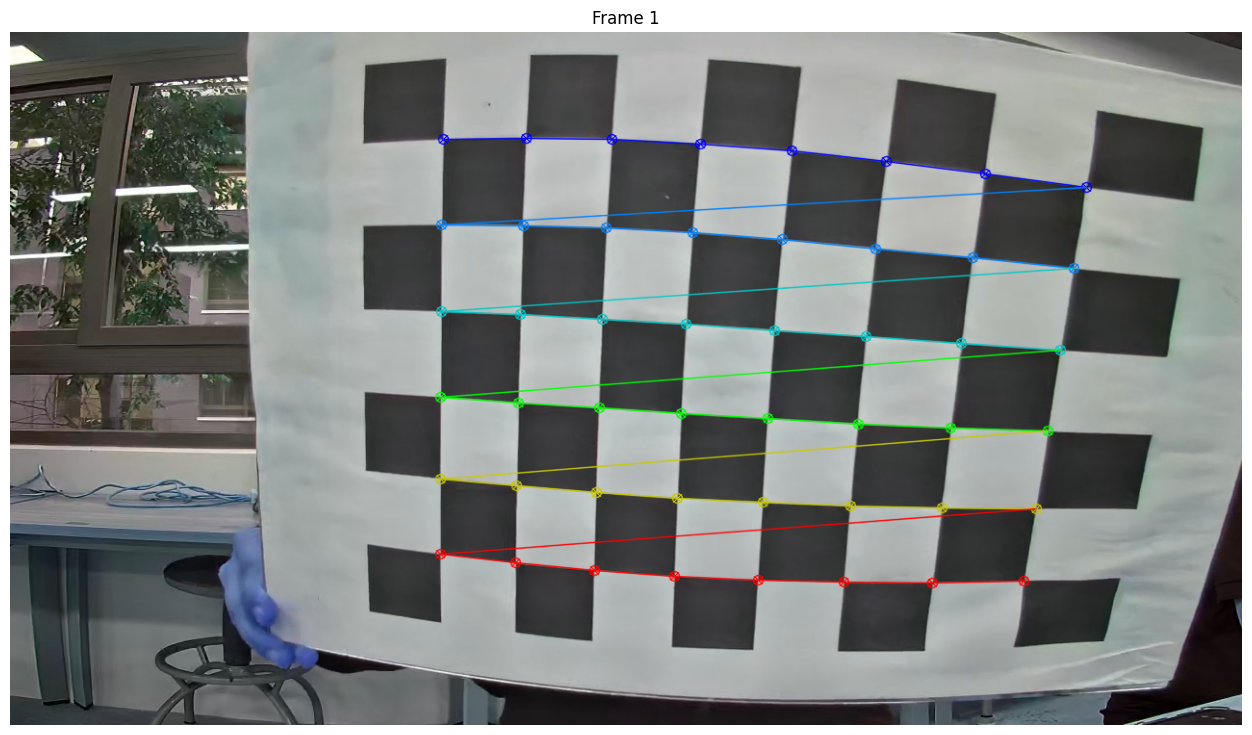

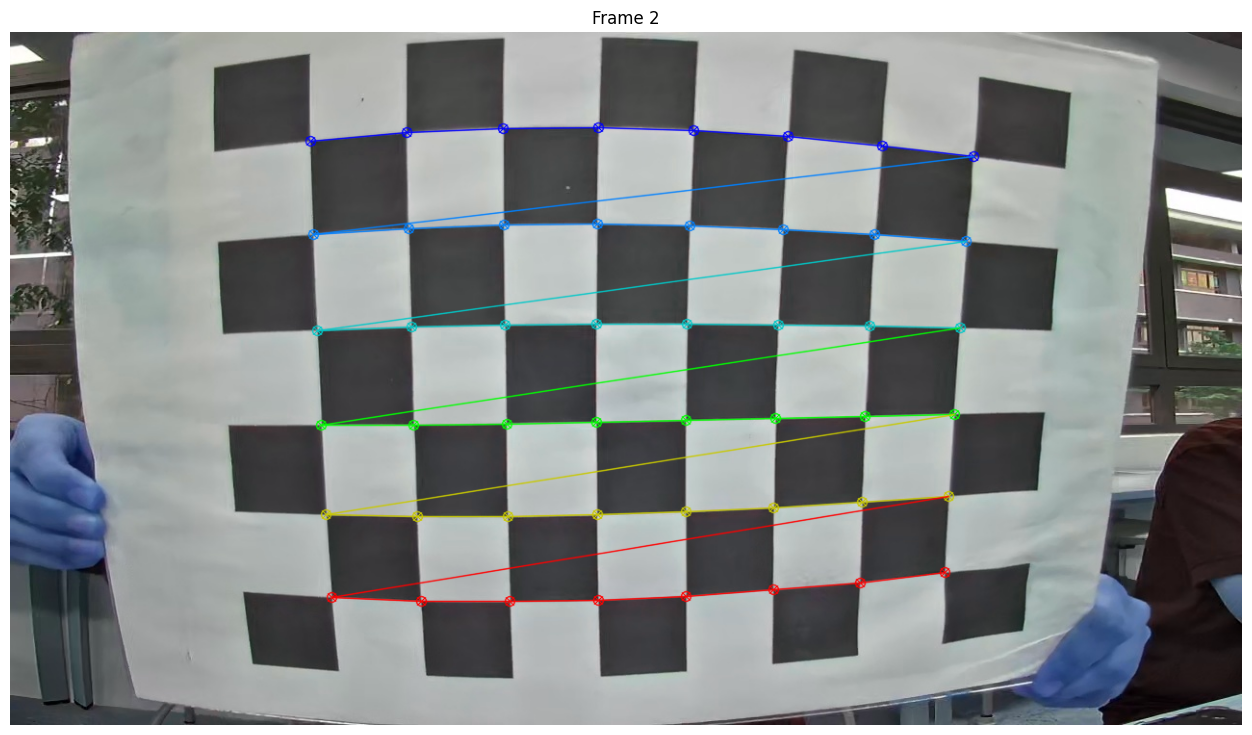

In [7]:
# Loop through a small set of calibration images to visualize corner detection
frame_ids = list(range(0, 3, 1))  # Adjust as needed for more images
for i in frame_ids:
    # Load the current image
    frame = cv2.imread(f"new_calib20_8/{i:02d}.jpg")
    
    # Find chessboard corners in the image
    ret, corners = cv2.findChessboardCorners(frame, board_shape, flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    
    # Refine corner locations to subpixel accuracy
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    corners_ref = cv2.cornerSubPix(gray_frame, corners, (11, 11), (-1, -1), criteria)
    
    # Draw the refined corners on the image for visualization 
    frame = cv2.drawChessboardCorners(frame, board_shape, corners_ref, ret)
    
    # Show the result
    plt.figure(figsize=(16, 9))
    plt.imshow(frame)
    plt.title(f"Frame {i}")
    plt.axis('off')
    plt.show()

In [8]:
# Loop through a small set of calibration images to visualize corner detection
frame_ids = list(range(0, 40, 1))  # Adjust as needed for more images
for i in frame_ids:
    # Load the current image
    frame = cv2.imread(f"new_calib20_8/{i:02d}.jpg")
    
    # Find chessboard corners in the image
    ret, corners = cv2.findChessboardCorners(frame, board_shape, flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    if ret: 
        # Refine corner locations to subpixel accuracy
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners_ref = cv2.cornerSubPix(gray_frame, corners, (11, 11), (-1, -1), criteria)
        
        # Draw the refined corners on the image for visualization 
        frame = cv2.drawChessboardCorners(frame, board_shape, corners_ref, ret)


        # Store the object points and image points for calibration
        objpoints.append(objp.copy())
        imgpoints.append(corners_ref)
        
        # Show the result
        # plt.figure(figsize=(16, 9))
        # SS
        # plt.title(f"Frame {i}")
        # plt.axis('off')
        # plt.show() 

## Camera Calibration
Using the collected points, we estimate the camera's intrinsic matrix and distortion coefficients. The RMS reprojection error indicates the calibration quality.

Using the collected points, we estimate the camera's intrinsic matrix and distortion coefficients. The RMS reprojection error indicates the calibration

In [9]:
# Set calibration flags
flags = cv2.CALIB_FIX_K3 | cv2.CALIB_USE_INTRINSIC_GUESS  # Fix k3 distortion, use initial guess for intrinsics

# Initial camera matrix setup (intrinsic parameters)
initial_fx = 1000.0  # Initial horizontal focal length
initial_fy = 1000.0  # Initial vertical focal length (square pixels)
image_width = 1280
image_height = 720
initial_cx = image_width / 2  # Principal point x
initial_cy = image_height / 2  # Principal point y
initial_camera_matrix = np.array([[initial_fx, 0, initial_cx],
                                [0, initial_fy, initial_cy],
                                [0, 0, 1]], dtype=np.float32)


# 1. Chuyển đổi thành List và ép kiểu float32
# objpoints_ready = [np.array(p, dtype=np.float32) for p in objpoints]
# imgpoints_ready = [np.array(p, dtype=np.float32) for p in imgpoints]

# # 2. Ép lại cấu trúc shape chuẩn (N, 1, 3) và (N, 1, 2)
# objpoints_ready = [p.reshape(-1, 1, 3) for p in objpoints_ready]
# imgpoints_ready = [p.reshape(-1, 1, 2) for p in imgpoints_ready]


# Run camera calibration using collected object and image points

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, img_shape, 
        cameraMatrix=initial_camera_matrix, distCoeffs=None,
        flags=flags, 
        criteria=criteria
    )

# Print calibration results
print("\n=== Calibration Results (LEFT) ===")
print(f"RMS reprojection error: {ret:.4f}")
print("K (intrinsics):\n", mtx)
print("dist (k1 k2 p1 p2 k3):\n", dist.ravel())
# In ra dạng số thực chi tiết (ví dụ: 0.000000123)
print("Real K      :")
for row in mtx:
    print([f"{x:.10f}" for x in row])
print("Real dist:")
print([f"{x:.10f}" for x in dist.ravel()])
# print("dist (k1 k2 p1 p2 k3):\n", dist)


=== Calibration Results (LEFT) ===
RMS reprojection error: 5.0132
K (intrinsics):
 [[902.39   0.   817.44]
 [  0.   877.48 337.57]
 [  0.     0.     1.  ]]
dist (k1 k2 p1 p2 k3):
 [-0.21  0.18  0.01  0.05  0.  ]
Real K      :
['902.3872464300', '0.0000000000', '817.4380012474']
['0.0000000000', '877.4839899029', '337.5717403128']
['0.0000000000', '0.0000000000', '1.0000000000']
Real dist:
['-0.2143448560', '0.1813371875', '0.0054192004', '0.0503781992', '0.0000000000']


# Undistoring Images
After calibration, we can remove lens distortion from images using the computed camera parameters. This improves measurement accuracy and visual quality

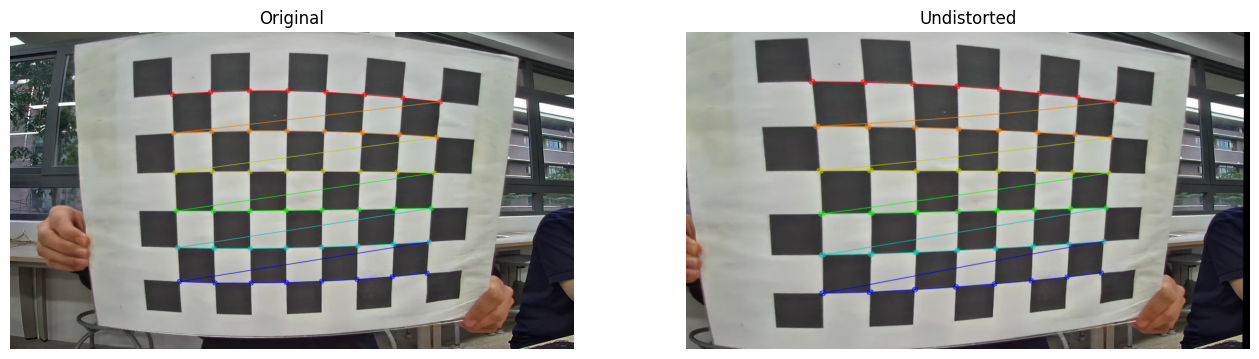

In [10]:
# Undistort the image using the computed camera matrix and distortion coefficients
undistorted = cv2.undistort(frame, mtx, dist)

# Visualize the original and undistorted images side by side
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.title("Original")
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.axis('off')
plt.title("Undistorted")
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.show()